In [ ]:
import os
import ast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [ ]:
df = pd.read_excel('imputed_df_xgb_1000iteration.xlsx').drop(
    ['Extrusion_Rate_Lengthwise_(mm/s)', 'Extrusion_Rate_Volume-wise_(mL/s)', 'chamber Temperature  (°C)'], axis=1)
df['Cell_Density_(cells/mL)'] = df['Cell_Density_(cells/mL)'] / 1e6

In [ ]:
targetless = df.drop(['Printability', 'Cell Response', 'Scaffold Quality (P*C)'], axis=1)

Saved resampled dataset for Printability as Printability_resampled_df.csv
Saved resampled dataset for Cell Response as Cell_Response_resampled_df.csv
Saved resampled dataset for Scaffold Quality (P*C) as Scaffold_Quality_(PxC)_resampled_df.csv


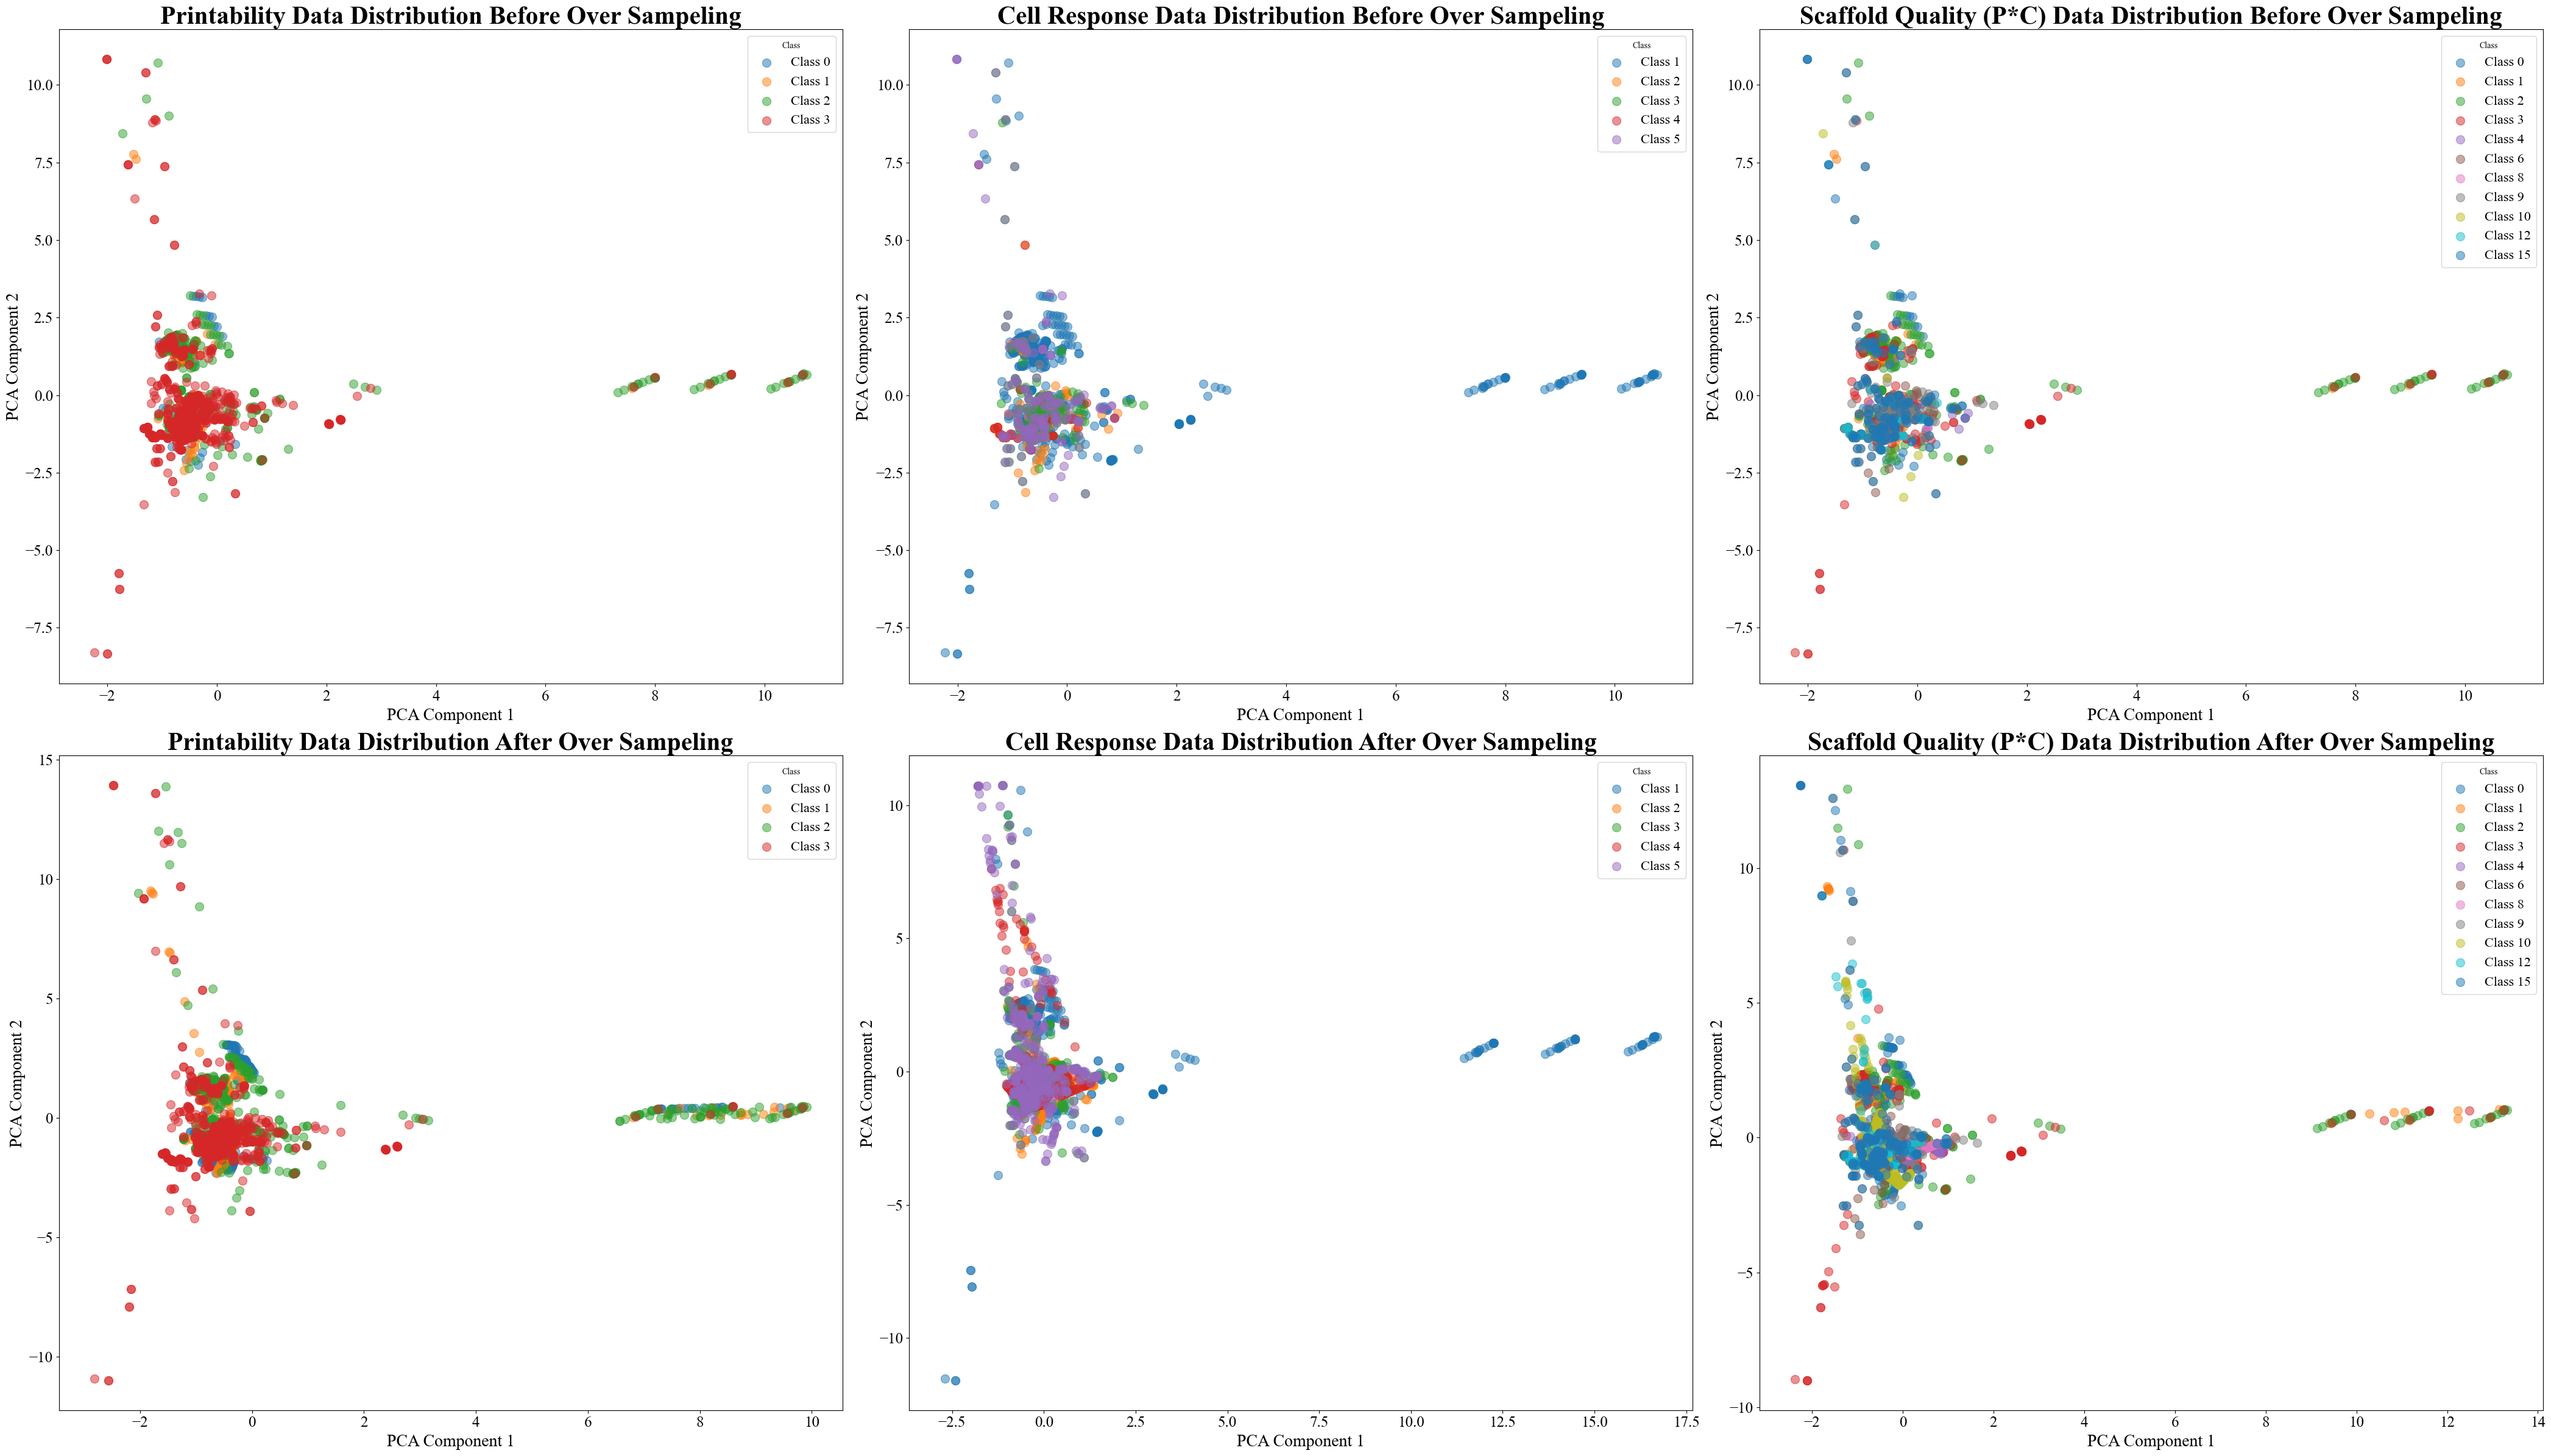

In [ ]:
class_counts = pd.DataFrame(columns=['Target', 'Class', 'Count Before Over Sampeling', 'Count After Over Sampeling'])
from collections import Counter

scaler = StandardScaler()
pca = PCA(n_components=2)
plt.figure(figsize=(42, 24))

targets = ['Printability', 'Cell Response', 'Scaffold Quality (P*C)']

for i, target in enumerate(targets, 1):
    X = scaler.fit_transform(targetless)
    y = df[target]
    classes_before = y.value_counts().reset_index()
    classes_before.columns = ['Class', 'Count Before Over Sampeling']
    X_pca = pca.fit_transform(X)

    plt.subplot(2, 3, i)
    classes = np.unique(y)
    for cls in classes:
        ix = np.where(y == cls)
        plt.scatter(X_pca[ix, 0], X_pca[ix, 1], label=f'Class {cls}', alpha=0.5, s=100)
    plt.title(f'{target} Data Distribution Before Over Sampeling', fontsize=30, fontweight='bold')
    plt.xlabel('PCA Component 1', fontsize=20)
    plt.ylabel('PCA Component 2', fontsize=20)
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.legend(title='Class', fontsize=16)

    if target == 'Scaffold Quality (P*C)':
        smote = SMOTE(random_state=42, k_neighbors=2)
    else:
        smote = SMOTE(random_state=42)

    X_resampled, y_resampled = smote.fit_resample(targetless, y)
    X_resampled_pca = pca.transform(scaler.fit_transform(X_resampled))


    y_resampled_df = pd.Series(y_resampled, name=target)

    resampled_df = pd.concat([X_resampled, y_resampled_df], axis=1)

    file_name = f"{target.replace(' ', '_').replace('*', 'x')}_resampled_df.csv"

    resampled_df.to_csv(file_name, index=False)
    print(f"Saved resampled dataset for {target} as {file_name}")


    classes_after = pd.Series(y_resampled).value_counts().reset_index()
    classes_after.columns = ['Class', 'Count After Over Sampeling']

    class_count = pd.merge(classes_before, classes_after, on='Class', how='outer')
    class_count['Target'] = target
    class_counts = pd.concat([class_counts, class_count], ignore_index=True)


    plt.subplot(2, 3, i + 3)
    classes_resampled = np.unique(y_resampled)
    for cls in classes_resampled:
        ix = np.where(y_resampled == cls)
        plt.scatter(X_resampled_pca[ix, 0], X_resampled_pca[ix, 1], label=f'Class {cls}', alpha=0.5, s=100)
    plt.title(f'{target} Data Distribution After Over Sampeling', fontsize=30, fontweight='bold')
    plt.xlabel('PCA Component 1', fontsize=20)
    plt.ylabel('PCA Component 2', fontsize=20)
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.legend(title='Class', fontsize=16)

plt.tight_layout()
plt.show()

In [ ]:
a = pd.read_csv("Printability_resampled_df.csv")

In [ ]:
count_1 = a["Printability"].value_counts()
count_1

Printability
3    650
2    650
0    650
1    650
Name: count, dtype: int64

In [ ]:
b = pd.read_csv("Cell_Response_resampled_df.csv")

In [ ]:
count_2 = b["Cell Response"].value_counts()
count_2

Cell Response
3    604
5    604
4    604
1    604
2    604
Name: count, dtype: int64

In [ ]:
c = pd.read_csv("Scaffold_Quality_(PxC)_resampled_df.csv")

In [ ]:
count_3 = c["Scaffold Quality (P*C)"].value_counts()
count_3

Scaffold Quality (P*C)
9     261
15    261
12    261
2     261
3     261
4     261
6     261
10    261
0     261
1     261
8     261
Name: count, dtype: int64

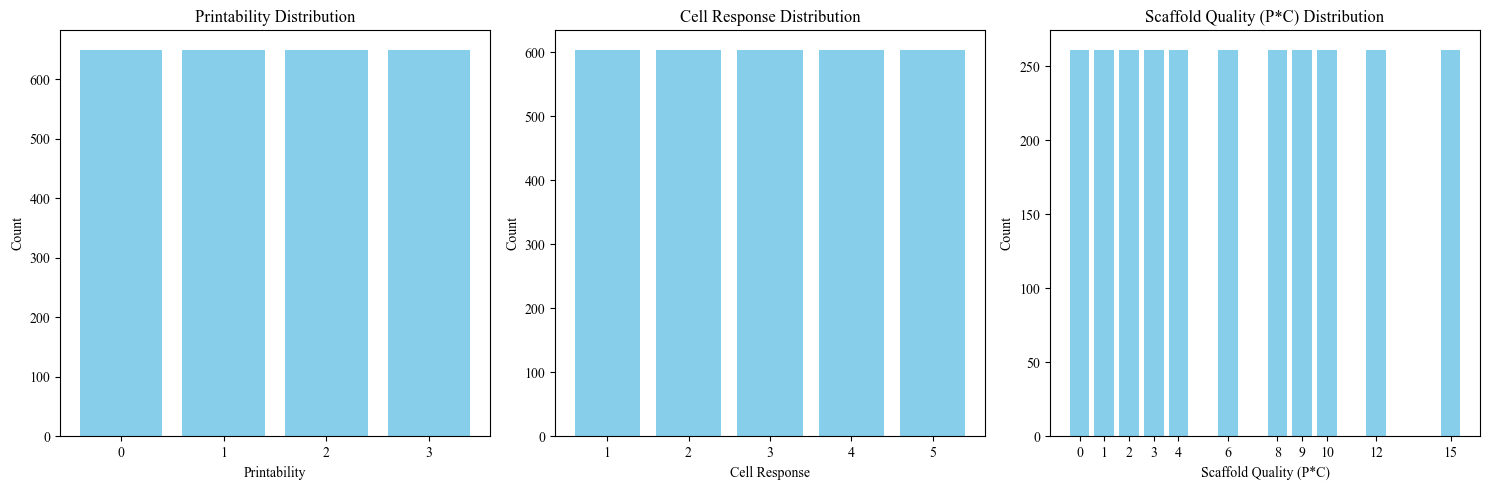

In [ ]:
import matplotlib.pyplot as plt

counts_list = [count_1, count_2, count_3]
labels = ["Printability", "Cell Response", "Scaffold Quality (P*C)"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, (counts, label) in enumerate(zip(counts_list, labels)):
    axes[i].bar(counts.index, counts.values, color='skyblue')
    axes[i].set_title(f"{label} Distribution")
    axes[i].set_xlabel(label)
    axes[i].set_ylabel("Count")
    axes[i].set_xticks(sorted(counts.index))

plt.tight_layout()
plt.show()

In [ ]:
class_counts

,Target,Class,Count Before Over Sampeling,Count After Over Sampeling
0,Printability,0,109,650
1,Printability,1,111,650
2,Printability,2,301,650
3,Printability,3,650,650
4,Cell Response,1,604,604
5,Cell Response,2,123,604
6,Cell Response,3,234,604
7,Cell Response,4,41,604
8,Cell Response,5,169,604
9,Scaffold Quality (P*C),0,109,261


In [ ]:
class_counts = pd.DataFrame(columns=['Target', 'Class', 'Count Before Over Sampeling', 'Count After Over Sampeling'])
from collections import Counter

scaler = StandardScaler()
pca = PCA(n_components=2)
plt.figure(figsize=(42, 24))

targets = ['Printability', 'Cell Response', 'Scaffold Quality (P*C)']

for i, target in enumerate(targets, 1):
    X = scaler.fit_transform(targetless)
    y = df[target]
    classes_before = y.value_counts().reset_index()
    classes_before.columns = ['Class', 'Count Before Over Sampeling']
    X_pca = pca.fit_transform(X)

    plt.subplot(2, 3, i)
    classes = np.unique(y)
    for cls in classes:
        ix = np.where(y == cls)
        plt.scatter(X_pca[ix, 0], X_pca[ix, 1], label=f'Class {cls}', alpha=0.5, s=100)
    plt.title(f'{target} Data Distribution Before Over Sampeling', fontsize=30, fontweight='bold')
    plt.xlabel('PCA Component 1', fontsize=20)
    plt.ylabel('PCA Component 2', fontsize=20)
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.legend(title='Class', fontsize=16)

    if target == 'Scaffold Quality (P*C)':
        smote = SMOTE(random_state=42, k_neighbors=2)
    else:
        smote = SMOTE(random_state=42)

    X_resampled, y_resampled = smote.fit_resample(targetless, y)
    X_resampled_pca = pca.transform(scaler.fit_transform(X_resampled))


    y_resampled_df = pd.Series(y_resampled, name=target)

    resampled_df = pd.concat([X_resampled, y_resampled_df], axis=1)

    file_name = f"{target.replace(' ', '_').replace('*', 'x')}_resampled_df.csv"

    resampled_df.to_csv(file_name, index=False)
    print(f"Saved resampled dataset for {target} as {file_name}")


    classes_after = pd.Series(y_resampled).value_counts().reset_index()
    classes_after.columns = ['Class', 'Count After Over Sampeling']

    class_count = pd.merge(classes_before, classes_after, on='Class', how='outer')
    class_count['Target'] = target
    class_counts = pd.concat([class_counts, class_count], ignore_index=True)


    plt.subplot(2, 3, i + 3)
    classes_resampled = np.unique(y_resampled)
    for cls in classes_resampled:
        ix = np.where(y_resampled == cls)
        plt.scatter(X_resampled_pca[ix, 0], X_resampled_pca[ix, 1], label=f'Class {cls}', alpha=0.5, s=100)
    plt.title(f'{target} Data Distribution After Over Sampeling', fontsize=30, fontweight='bold')
    plt.xlabel('PCA Component 1', fontsize=20)
    plt.ylabel('PCA Component 2', fontsize=20)
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.legend(title='Class', fontsize=16)

plt.tight_layout()
plt.show()